# Week 4b — Wind Capacity-Factor Forecast

`wind` (`EMBEDDED_WIND_GENERATION`) is a same-period actual — no free historical forecast archive exists for it (unlike weather). This notebook builds a genuine forecast for it instead: `capacity_factor ~ f(wind speed forecast, calendar)` (PLAN.md Week 4b), evaluated on its own merits first (own MAE/RMSE against a seasonal-naive capacity-factor baseline), before any question of feeding it into the demand model.

**Hypothesis:** wind generation is driven almost entirely by wind speed (a strongly nonlinear but well-understood physical relationship), so a weather-driven model should beat a seasonal-naive capacity-factor baseline by a wide margin — weather doesn't repeat on a weekly cycle the way demand partly does, so "same time last week" is a much weaker prior here than it is for demand.

**Same structural constraint as Week 4's weather ablation**: day-ahead wind-speed forecasts only exist from 2024-03-07 onward, with zero overlap with `TRAIN` (2020-2023). So the model is trained on ERA5 (hindsight) wind speed, then — for the honest check — evaluated with genuine day-ahead wind speed swapped in at inference time for the slice where that exists.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.models.baselines import previous_week_same_time
from edf.data.weather import DAY_AHEAD_ARCHIVE_START
from edf.evaluate import evaluate
from edf.models.forecast import train_lightgbm
from edf.features.generation import build_wind_feature_table, capacity_factor
from edf.tracking import log_model_run
from edf.models.tuning import tune_lightgbm, walk_forward_cv_folds
from edf.features.weather import build_weather_feature_table

pd.options.display.float_format = "{:.4f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")

2026/09/07 11:26:14 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

wind_cf = capacity_factor(df["wind"], df["wind_capacity"])
wind_cf.loc[val_start:val_end].describe()

count   17568.0000
mean        0.2937
std         0.1924
min         0.0349
25%         0.1404
50%         0.2434
75%         0.4083
max         0.9003
dtype: float64

## Seasonal-naive capacity-factor baseline (the number the model must beat)

In [3]:
naive_cf_val = previous_week_same_time(wind_cf).loc[val_start:val_end]
naive_mae = evaluate(wind_cf.loc[val_start:val_end], naive_cf_val)["mae"]
naive_mae

0.1979330639098701

## Tune + train on ERA5 (hindsight) wind speed

In [4]:
era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
X, y = build_wind_feature_table(df, era5)
X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]

folds = walk_forward_cv_folds(X_train.index)
t0 = time.time()
best_params, best_n, trials = tune_lightgbm(X_train, y_train, folds, n_trials=10)
tune_seconds = time.time() - t0
model = train_lightgbm(X_train, y_train, n_estimators=best_n, **best_params)
print(f"best={best_params}, n_estimators={best_n}, tune={tune_seconds:.0f}s")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 17568, number of used features: 16
[LightGBM] [Info] Start training from score 0.319047


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 35088, number of used features: 16
[LightGBM] [Info] Start training from score 0.289224


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 52608, number of used features: 16
[LightGBM] [Info] Start training from score 0.289258


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000357 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 17568, number of used features: 16
[LightGBM] [Info] Start training from score 0.319047


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 35088, number of used features: 16
[LightGBM] [Info] Start training from score 0.289224


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 52608, number of used features: 16
[LightGBM] [Info] Start training from score 0.289258


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 17568, number of used features: 16
[LightGBM] [Info] Start training from score 0.319047


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 35088, number of used features: 16
[LightGBM] [Info] Start training from score 0.289224


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 52608, number of used features: 16
[LightGBM] [Info] Start training from score 0.289258


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 70128, number of used features: 16
[LightGBM] [Info] Start training from score 0.285018
best={'num_leaves': 15, 'min_child_samples': 50, 'learning_rate': 0.1}, n_estimators=29, tune=35s


## Own-merit evaluation: does the weather-driven model beat seasonal-naive?

Note on `mape`: capacity factor sits near zero during low-wind periods, and `edf.evaluate.mape` divides by the actual value — exactly the condition its own docstring flags as unstable. MAE/RMSE/MASE are the metrics to trust here; `mape` is reported only for consistency with every other table in this project, not because it's a reliable number for this particular target.

In [5]:
preds_era5 = pd.Series(model.predict(X_val), index=X_val.index)
m_era5 = evaluate(y_val, preds_era5, seasonal_naive_mae=naive_mae)
pd.Series(m_era5)

mae                 0.0827
rmse                0.1083
mape               36.3335
bias                0.0139
p95_abs_error       0.2197
n               17568.0000
mase                0.4179
dtype: float64

## Finding: hypothesis confirmed, and decisively

MAE 0.0827 vs. the seasonal-naive baseline's 0.1979 — a **58% reduction**, MASE 0.418. This is a much bigger relative gain than weather gave the demand model (27.65%), which makes sense: weather has almost no persistent weekly pattern to exploit, so "same half-hour last week" (the seasonal-naive baseline) is a genuinely weak prior for wind — unlike demand, where weekly routines make that baseline much harder to beat.

## Honest check: same model, genuine day-ahead wind speed at inference, `2024-03-07`-onward

In [6]:
day_ahead = build_weather_feature_table("open_meteo_day_ahead", df.index, raw_dir=WEATHER_RAW_DIR)
X_day_ahead, y_day_ahead = build_wind_feature_table(df, day_ahead)

slice_start = str(DAY_AHEAD_ARCHIVE_START.date())
y_slice = y_val.loc[slice_start:val_end]
naive_mae_slice = evaluate(
    wind_cf.loc[slice_start:val_end], naive_cf_val.loc[slice_start:val_end]
)["mae"]

preds_era5_slice = preds_era5.loc[slice_start:val_end]
X_da_slice = X_day_ahead.loc[slice_start:val_end]
preds_day_ahead_slice = pd.Series(model.predict(X_da_slice), index=X_da_slice.index)

m_era5_slice = evaluate(y_slice, preds_era5_slice, seasonal_naive_mae=naive_mae_slice)
m_day_ahead_slice = evaluate(
    wind_cf.loc[preds_day_ahead_slice.index], preds_day_ahead_slice, seasonal_naive_mae=naive_mae_slice
)

honest = pd.DataFrame({"era5": m_era5_slice, "day_ahead": m_day_ahead_slice}).T
print(f"Slice: {slice_start} to {val_end}, n={len(y_slice)}")
honest

Slice: 2024-03-07 to 2024-12-31, n=14400


,mae,rmse,mape,bias,p95_abs_error,n,mase
era5,0.0818,0.1091,36.2095,0.0214,0.2297,14400.0000,0.4264
day_ahead,0.0803,0.1074,35.4225,0.0240,0.2321,14400.0000,0.4182


## Finding: the day-ahead-vs-ERA5 pattern repeats, this time without the bias story

Same qualitative result as Week 4's demand-model ablation: day-ahead-fed evaluation (MAE 0.0803) scores marginally *better* than ERA5-fed (MAE 0.0818) on the identical trained model and target rows. But this time `bias` doesn't explain it — both are similarly small and positive (0.021 ERA5 vs. 0.024 day-ahead), not the large gap seen in the demand-model case. So here it's more likely genuine noise in exactly which half-hours the two wind-speed sources happen to get right on this one ~10-month window, not a systematic effect. Either way, the practical conclusion is the same as before: **the gap between ERA5-based and day-ahead-based accuracy is small, so the wind-forecasting gain is real, not a hindsight-only artifact.**

## Feature importance

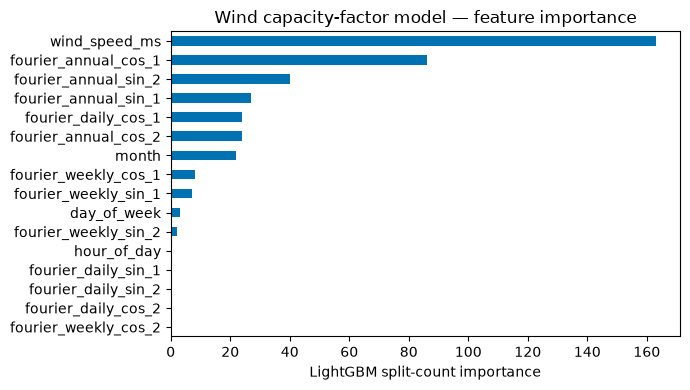

In [7]:
importance = pd.Series(model.feature_importances_, index=model.feature_name_).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
importance.iloc[::-1].plot.barh(ax=ax, color="#0072B2")
ax.set_title("Wind capacity-factor model — feature importance")
ax.set_xlabel("LightGBM split-count importance")
fig.tight_layout()

## Plot: actual vs. predicted wind capacity factor, one week

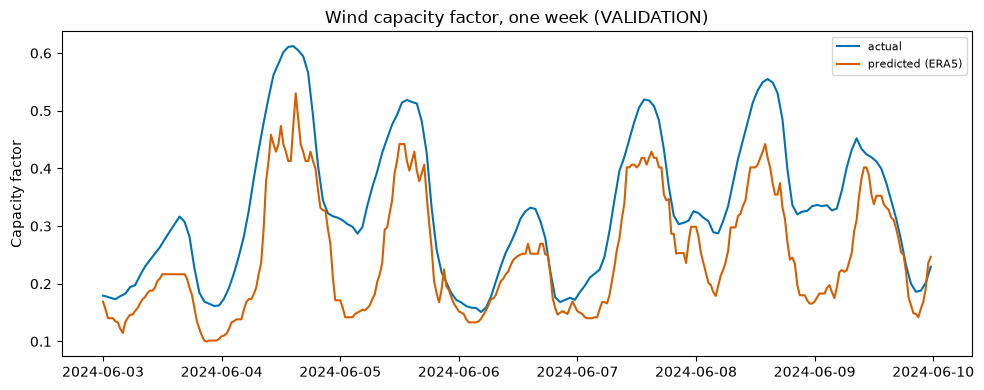

In [8]:
window = slice("2024-06-03", "2024-06-09")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_val.loc[window].index, y_val.loc[window], label="actual", color="#0072B2")
ax.plot(preds_era5.loc[window].index, preds_era5.loc[window], label="predicted (ERA5)", color="#D55E00")
ax.set_title("Wind capacity factor, one week (VALIDATION)")
ax.set_ylabel("Capacity factor")
ax.legend(fontsize=8)
fig.tight_layout()

## Finding: the model tracks timing well but underestimates peak generation

The one-week plot shows the model correctly catching *when* wind picks up and drops (peak timing lines up closely with actual), but it visibly underestimates the *height* of high-wind peaks — e.g. the 2024-06-04 peak reaches ≈0.61 actual vs. ≈0.53 predicted, and 2024-06-08's reaches ≈0.55 vs. ≈0.44. The average `bias` (0.014) looks small precisely because it's averaged over the whole distribution, masking a bigger gap concentrated at the high end. A plausible cause, tied to a limitation already documented in `PLAN.md`: weather here is population-weighted across 5 GB cities, a coarse proxy — wind farms are predominantly rural/coastal, not co-located with population centres, and plausibly see systematically higher wind speeds than the population-weighted average during high-wind events specifically. Worth a real fix (e.g. weighting by wind-farm location instead of population for this one model) if wind forecasting becomes more central to the project; noted here rather than fixed, since it doesn't change today's conclusion.

## Log to MLflow

In [9]:
log_model_run(
    horizon_name="1d",
    horizon_periods=config.HORIZONS["1d"],
    model_name="lightgbm",
    fold_metrics=pd.DataFrame([m_era5], index=pd.Index([2024], name="year")),
    extra_tags={"strategy": "direct", "tuned": "true", "target": "wind_capacity_factor"},
    extra_params={**best_params, "n_estimators": best_n},
    extra_metrics={"tune_seconds": tune_seconds},
)
print("Logged wind capacity-factor run to MLflow (forecast-1d experiment)")

Logged wind capacity-factor run to MLflow (forecast-1d experiment)
